# Routing | Orchestrator | Evaluator Optimizer

In [1]:
import json
import warnings
from typing import Any, Literal

import numpy as np
import pandas as pd
import polars as pl
from rich.console import Console
from rich.theme import Theme

custom_theme = Theme(
    {
        "white": "#FFFFFF",  # Bright white
        "info": "#00FF00",  # Bright green
        "warning": "#FFD700",  # Bright gold
        "error": "#FF1493",  # Deep pink
        "success": "#00FFFF",  # Cyan
        "highlight": "#FF4500",  # Orange-red
    }
)
console = Console(theme=custom_theme)

# Visualization
# import matplotlib.pyplot as plt

# NumPy settings
np.set_printoptions(precision=4)

# Pandas settings
pd.options.display.max_rows = 1_000
pd.options.display.max_columns = 1_000
pd.options.display.max_colwidth = 600

# Polars settings
pl.Config.set_fmt_str_lengths(1_000)
pl.Config.set_tbl_cols(n=1_000)
pl.Config.set_tbl_rows(n=200)

warnings.filterwarnings("ignore")

# Black code formatter (Optional)
%load_ext lab_black

# auto reload imports
%load_ext autoreload
%autoreload 2

In [2]:
def go_up_from_current_directory(*, go_up: int = 1) -> None:
    """This is used to up a number of directories.

    Params:
    -------
    go_up: int, default=1
        This indicates the number of times to go back up from the current directory.

    Returns:
    --------
    None
    """
    import os
    import sys

    CONST: str = "../"
    NUM: str = CONST * go_up

    # Goto the previous directory
    prev_directory = os.path.join(os.path.dirname(__name__), NUM)
    # Get the 'absolute path' of the previous directory
    abs_path_prev_directory = os.path.abspath(prev_directory)

    # Add the path to the System paths
    sys.path.insert(0, abs_path_prev_directory)
    print(abs_path_prev_directory)


# Demo (Prevents ruff from removing the unused module import)
name: Any
category: Literal["A", "B", "C"]
json.loads('{"name": "Bike Rental Prediction", "category": "A"}')

{'name': 'Bike Rental Prediction', 'category': 'A'}

In [3]:
go_up_from_current_directory(go_up=2)

from model_config import LocalModel, RemoteModel  # noqa: E402
from settings import refresh_settings  # noqa: E402

settings = refresh_settings()

/Users/mac/Desktop/Projects/RAG-Tutorials


In [4]:
from langchain_openai import ChatOpenAI

remote_llm = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),  # type: ignore
    base_url=settings.OPENROUTER_URL,
    temperature=0.0,
    model=RemoteModel.X_AI_GROK_4_FAST,
)


# Test the LLMs
response = remote_llm.invoke("Tell me a very short joke.")
response.pretty_print()

================================== Ai Message ==================================

Why don't scientists trust atoms? Because they make up everything!


<br><hr>

# Routing

<br>

<img src="https://i.postimg.cc/KvcqZ0hY/image.png" width=300> </img>

<br>

- Routing in LangGraph refers to the ability to conditionally determine which node to execute next based on the current state or the output of a node. 

- This is typically implemented using:

  - `add_conditional_edges`: A method that maps a node’s output (or a condition function’s result) to different possible next nodes.

  - `State`: The workflow’s state can store variables that influence routing decisions.

  - `Condition Functions`: Functions that evaluate the state or node output to decide the next step.

### Key Concepts

- `Dynamic Flow`: Unlike a linear sequence, routing lets the graph adapt to intermediate results.

- `Condition Logic`: You define rules (e.g., "if this, go here; if that, go there").

- `Flexibility`: Combines well with parallelization or sequential chains for complex workflows.

In [5]:
from typing import Annotated, TypedDict

from langchain_core.messages import (
    AIMessage,
    AnyMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage,
)
from langchain_core.tools import tool
from langgraph.graph.message import add_messages

In [14]:
from IPython.display import Image, Markdown, display
from langchain_core.runnables import RunnableConfig
from langchain_core.runnables.graph_mermaid import MermaidDrawMethod
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph

### Create A Simple Graph

In [20]:
from enum import Enum
from pydantic import BaseModel, Field


type PydanticModel = type[BaseModel]


class Topics(str, Enum):
    SPORTS = "sports"
    TECHNOLOGY = "technology"
    RELIGION = "religion"
    OTHERS = "others"


class State(TypedDict):
    user_input: str
    router_output: Topics
    final_story: str


class TopicsSchema(BaseModel):
    topic: Topics = Field(..., description="The topic of the story")


valid_topics: list[str] = [topic.value for topic in Topics if topic != Topics.OTHERS]

# ==================================================================
# ============================ PROMPTS =============================
# ==================================================================
sports_prompt: str = """
<INSTR>
You're a helpful sports writer. Create a short story of about 2 sentences about this 
<USER_INPUT>{user_input}</USER_INPUT>
</INSTR> 
"""

technology_prompt: str = """
<INSTR>
You're a helpful technology writer. Create a short story of about 2 sentences about this 
<USER_INPUT>{user_input}</USER_INPUT>
</INSTR> 
"""

religion_prompt: str = """
<INSTR>
You're a helpful religion writer. Create a short story of about 2 sentences about this 
<USER_INPUT>{user_input}</USER_INPUT>

<GUIDELINES>
1. Be concise and stay on topic.
2. Use clear and simple language.
3. This is a sensitive topic; approach with respect and neutrality.
</GUIDELINES>
</INSTR> 
"""

others_prompt: str = """
<INSTR>
You're a friendly assistant that helps users create short stories based on the: 
<TOPICS>{topics}</TOPICS>

<GUIDELINES>
- Ask the user about which topic they would like a story on.
- Your response should ONLY be a question about the topic they want.
</GUIDELINES>
</INSTR> 
"""


remote_llm = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),
    base_url=settings.OPENROUTER_URL,
    temperature=0.85,
    model=RemoteModel.X_AI_GROK_4_FAST,
)

_router_llm = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),
    base_url=settings.OPENROUTER_URL,
    temperature=0.0,
    model=RemoteModel.GEMINI_2_0_FLASH_001,
)


async def router_llm(state: State) -> dict[str, Any]:
    """Call the remote LLM with the provided messages."""
    llm_with_structured_output = _router_llm.with_structured_output(TopicsSchema)
    response = await llm_with_structured_output.ainvoke(input=state["user_input"])

    return {"router_output": response.topic}


async def call_llm_1(state: State) -> dict[str, Any]:
    """Call the remote LLM with the provided messages."""
    prompt: str = sports_prompt.format(user_input=state["user_input"])
    response = await remote_llm.ainvoke(input=prompt)

    return {"final_story": response.content}


async def call_llm_2(state: State) -> dict[str, Any]:
    """Call the remote LLM with the provided messages."""
    prompt: str = technology_prompt.format(user_input=state["user_input"])
    response = await remote_llm.ainvoke(input=prompt)

    return {"final_story": response.content}


async def call_llm_3(state: State) -> dict[str, Any]:
    """Call the remote LLM with the provided messages."""
    prompt: str = religion_prompt.format(user_input=state["user_input"])
    response = await remote_llm.ainvoke(input=prompt)

    return {"final_story": response.content}


async def call_llm_4(state: State) -> dict[str, Any]:
    """Call the remote LLM with the provided messages."""
    prompt: str = others_prompt.format(topics=valid_topics)
    response = await remote_llm.ainvoke(input=prompt)

    return {"final_story": response.content}


def decide_next_node(
    state: State,
) -> Literal["call_llm_1", "call_llm_2", "call_llm_3", "call_llm_4"]:
    """Decide the next node based on the router output."""
    topic: Topics = state.get("router_output", Topics.OTHERS)

    if topic == Topics.SPORTS:
        return "call_llm_1"
    if topic == Topics.TECHNOLOGY:
        return "call_llm_2"
    if topic == Topics.RELIGION:
        return "call_llm_3"
    return "call_llm_4"

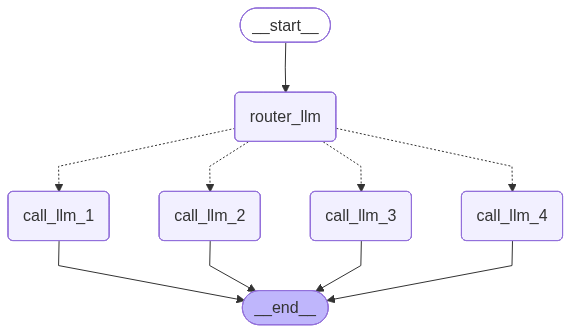

In [22]:
builder = StateGraph(State)

# Nodes
builder.add_node("router_llm", router_llm)
builder.add_node("call_llm_1", call_llm_1)
builder.add_node("call_llm_2", call_llm_2)
builder.add_node("call_llm_3", call_llm_3)
builder.add_node("call_llm_4", call_llm_4)


# Edges
builder.add_edge(START, "router_llm")
builder.add_conditional_edges("router_llm", decide_next_node)
builder.add_edge("call_llm_1", END)
builder.add_edge("call_llm_2", END)
builder.add_edge("call_llm_3", END)
builder.add_edge("call_llm_4", END)

# Compile the graph
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

# Visualize the graph using nest_asyncio to handle event loop
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [ ]:
# Re-build the graph
graph = builder.compile(checkpointer=memory)

config: dict[str, Any] = {"configurable": {"thread_id": "1"}}

response = await graph.ainvoke(
    {"user_input": "Rev. Fr. Patrick"},
    config=config,
)

console.print(response)

In [ ]:
Markdown(response["final_story"])

<br><hr>

# Orchestrator

In the orchestrator-workers workflow, a central LLM dynamically breaks down tasks, delegates them to worker LLMs, and synthesizes their results.

## When to use this workflow

- This workflow is well-suited for complex tasks where you can't predict the subtasks needed (in coding, for example, the number of files that need to be changed and the nature of the change in each file likely depend on the task). 

- Although it shares a comparable topology, the primary distinction from parallelization lies in its adaptability. Subtasks are **not fixed** in advance but **dynamically assigned** by the orchestrator according to the particular input.

<br>

[![image.png](https://i.postimg.cc/Z5nfGmWY/image.png)](https://postimg.cc/MnkbBh0g)

### Creating Workers Dynamically In LangGraph

- Because orchestrator-worker workflows are common, LangGraph has the Send API to support this. It lets you dynamically create worker nodes and send each one a specific input.

- Each worker has its own state, and all worker outputs are written to a shared state key that is accessible to the orchestrator graph.

- This gives the orchestrator access to all worker output and allows it to synthesize them into a final output.

- `Send` is used to create and send inputs to worker nodes dynamically.

<br>

  ```py
  from langgraph.constants import Send
  ```

<br>